# Skull-Stripping Correction for P28--P39

**Dataset:** Cyprus PROTEAS Brain Metastases (Flouri et al., 2025)

## Problem
During Phase 1 EDA, we identified that patients P28--P39 retain extracranial tissue (scalp, skull, muscles) in their BraTS MRI volumes, while P01--P27 and P40 are properly skull-stripped. This inconsistency affects intensity normalization, radiomic feature extraction, and neural network input consistency.

## Solution
The dataset provides brain mask files (`P??_brain_mask.nii.gz`) for all patients. These masks contain labels 10 (ventricles), 30 (white matter), 40 (grey matter), and 50 (CSF).

We use these masks to:
1. Create a binary brain mask (any label > 0 = brain)
2. Apply the mask to all 4 MRI modalities (T1, T2, T1c, FLAIR) for all visits
3. Save the skull-stripped volumes back in the same location (with backup)
4. Verify the results by comparing non-zero voxel percentages before and after

In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from tqdm import tqdm
import shutil
import pandas as pd

DATA_ROOT = Path('/home/moamed/canada_me/explainable_diseas/implementation_cyprus/Data/Cyprus-PROTEAS-zips')
OUTPUT_DIR = Path('/home/moamed/canada_me/explainable_diseas/implementation_cyprus/outputs')
BACKUP_DIR = OUTPUT_DIR / 'pre_skullstrip_backup'

all_patients = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir() and p.name.startswith('P')])
print(f'Total patients: {len(all_patients)}')

Total patients: 45


## Step 1: Identify Affected Patients

We measure the percentage of non-zero voxels in each patient's baseline T1c scan. Skull-stripped brains occupy approximately 13--19% of the 240x240x155 voxel grid, while non-stripped heads occupy 44--85%.

Checking skull-strip status: 100%|██████████| 45/45 [00:04<00:00,  9.06it/s]


Originally stripped: 33/45
Already corrected:   12/45 (from previous run)
Still need stripping: 0/45

All patients are already skull-stripped. No action needed.
Previously corrected patients: ['P28', 'P29', 'P30', 'P31', 'P32', 'P33', 'P34', 'P35', 'P36', 'P37', 'P38', 'P39']


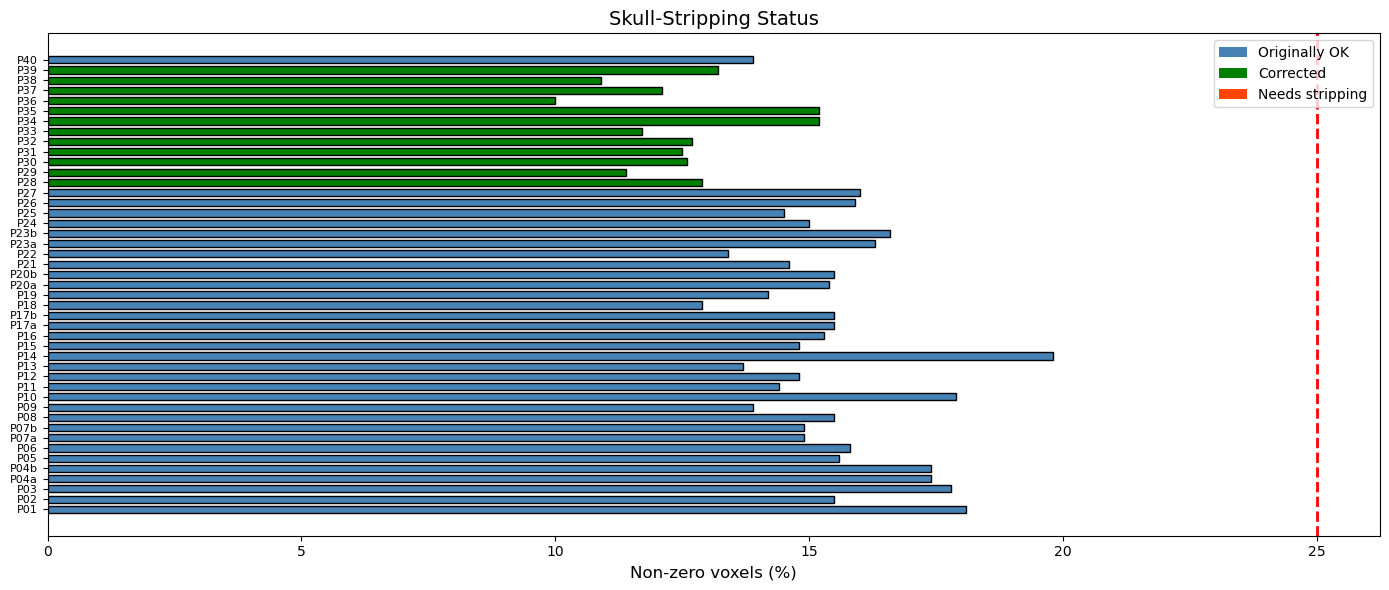

In [5]:
# Measure non-zero percentage for all patients
# Also check if backups exist (= already stripped in a previous run)
strip_data = []
for patient in tqdm(all_patients, desc='Checking skull-strip status'):
    t1c = DATA_ROOT / patient / 'BraTS' / 'baseline' / 't1c.nii.gz'
    bm = DATA_ROOT / patient / f'{patient}_brain_mask.nii.gz'
    if not t1c.exists(): continue
    d = nib.load(t1c).get_fdata()
    nz_pct = (d != 0).sum() / d.size * 100
    has_bm = bm.exists()
    has_backup = (BACKUP_DIR / patient / 'baseline' / 't1c.nii.gz').exists()
    # If backup exists but data looks stripped, it was already fixed
    if has_backup and nz_pct < 25:
        status = 'Already corrected'
    elif nz_pct < 25:
        status = 'Stripped'
    else:
        status = 'NOT stripped'
    strip_data.append({'Patient': patient, 'NonZero_Pct': round(nz_pct, 1),
                       'Status': status, 'BrainMask': has_bm,
                       'Max_Val': float(d.max()), 'HasBackup': has_backup})

df_strip = pd.DataFrame(strip_data)
affected = df_strip[df_strip['Status'] == 'NOT stripped']
corrected = df_strip[df_strip['Status'] == 'Already corrected']
ok = df_strip[df_strip['Status'] == 'Stripped']

print(f'Originally stripped: {len(ok)}/{len(df_strip)}')
print(f'Already corrected:   {len(corrected)}/{len(df_strip)} (from previous run)')
print(f'Still need stripping: {len(affected)}/{len(df_strip)}')

if len(affected) == 0 and len(corrected) > 0:
    print(f'\nAll patients are already skull-stripped. No action needed.')
    print(f'Previously corrected patients: {list(corrected["Patient"])}')
elif len(affected) > 0:
    print(f'\nAffected patients:')
    print(affected[['Patient', 'NonZero_Pct', 'BrainMask', 'Max_Val']].to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
color_map = {'Stripped': 'steelblue', 'NOT stripped': 'orangered', 'Already corrected': 'green'}
colors = [color_map[s] for s in df_strip['Status']]
ax.barh(df_strip['Patient'], df_strip['NonZero_Pct'], color=colors, edgecolor='k', height=0.7)
ax.axvline(25, color='red', ls='--', lw=2, label='Threshold (25%)')
ax.set_xlabel('Non-zero voxels (%)', fontsize=12)
ax.set_title('Skull-Stripping Status', fontsize=14)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(fc='steelblue', label='Originally OK'),
                   Patch(fc='green', label='Corrected'),
                   Patch(fc='orangered', label='Needs stripping')], fontsize=10)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

## Step 2: Visual Comparison Before Stripping

Side-by-side comparison of a properly stripped patient vs an affected patient, showing why extracerebral tissue is a problem.

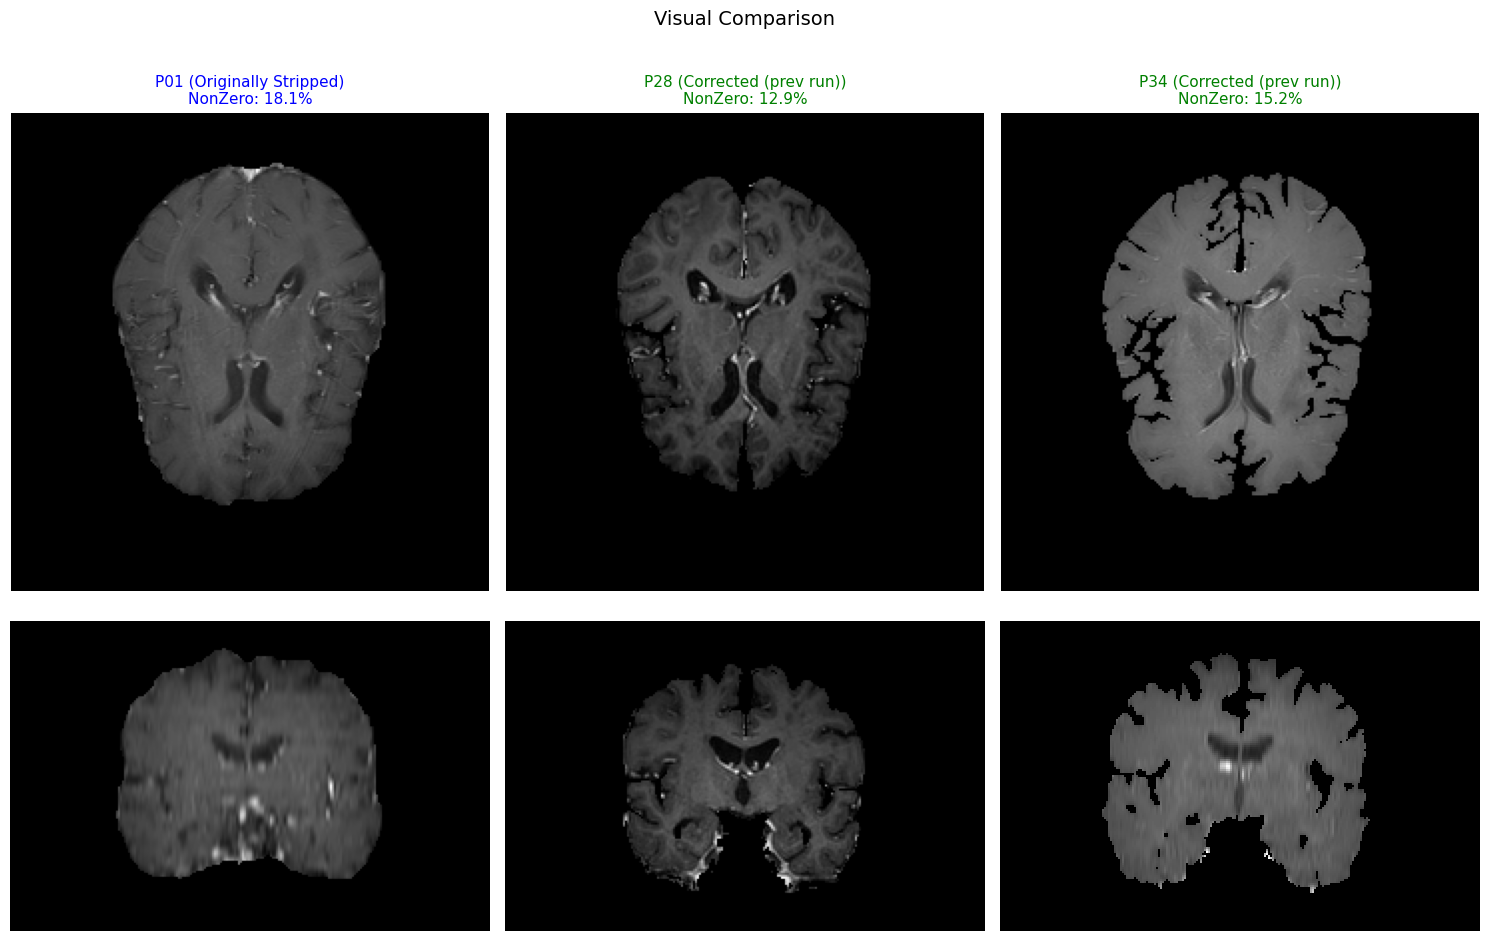

In [6]:
# Visual comparison: stripped vs corrected vs not-stripped
# Pick examples based on what's available
examples = []
if len(ok) > 0:
    examples.append((ok.iloc[0]['Patient'], 'Originally Stripped'))
if len(corrected) > 0:
    examples.append((corrected.iloc[0]['Patient'], 'Corrected (prev run)'))
    if len(corrected) > 1:
        examples.append((corrected.iloc[len(corrected)//2]['Patient'], 'Corrected (prev run)'))
if len(affected) > 0:
    examples.append((affected.iloc[0]['Patient'], 'NOT Stripped'))
    if len(affected) > 1:
        examples.append((affected.iloc[len(affected)//2]['Patient'], 'NOT Stripped'))

# Pad to at least 2
while len(examples) < 2 and len(ok) > len(examples):
    examples.append((ok.iloc[len(examples)]['Patient'], 'Originally Stripped'))

ncols = len(examples)
if ncols == 0:
    print('No patients to visualize')
else:
    fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 10))
    if ncols == 1: axes = axes.reshape(-1, 1)
    
    for col, (patient, label) in enumerate(examples):
        t1c = nib.load(DATA_ROOT / patient / 'BraTS' / 'baseline' / 't1c.nii.gz').get_fdata()
        mid_z = t1c.shape[2] // 2
        mid_y = t1c.shape[1] // 2
        nz = (t1c != 0).sum() / t1c.size * 100
        color = 'green' if 'Corrected' in label else ('red' if 'NOT' in label else 'blue')
        
        axes[0, col].imshow(np.rot90(t1c[:, :, mid_z]), cmap='gray')
        axes[0, col].set_title(f'{patient} ({label})\nNonZero: {nz:.1f}%', fontsize=11, color=color)
        axes[0, col].axis('off')
        if col == 0: axes[0, col].set_ylabel('Axial', fontsize=12)
        
        axes[1, col].imshow(np.rot90(t1c[:, mid_y, :]), cmap='gray')
        axes[1, col].axis('off')
        if col == 0: axes[1, col].set_ylabel('Coronal', fontsize=12)
    
    plt.suptitle('Visual Comparison', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## Step 3: Apply Skull-Stripping

For each affected patient (P28--P39), we:
1. Load the brain mask (`P??_brain_mask.nii.gz`)
2. Create a binary mask: any voxel with label > 0 is brain tissue
3. Back up the original MRI files to `outputs/pre_skullstrip_backup/`
4. Apply the mask to all 4 modalities (T1, T2, T1c, FLAIR) for ALL visits (baseline + follow-ups)
5. Save the masked volumes in place

The brain mask labels (10=ventricles, 30=WM, 40=GM, 50=CSF) together cover the entire intracranial space. Setting everything outside this mask to zero removes scalp, skull, and other extracranial tissue.

In [7]:
# SKULL-STRIPPING: Apply brain mask to affected patients
if len(affected) == 0:
    print('No patients need skull-stripping. All already corrected.')
    results = []
    affected_patients = []
else:
    BACKUP_DIR.mkdir(parents=True, exist_ok=True)
    modalities = ['t1.nii.gz', 't1c.nii.gz', 't2.nii.gz', 'fla.nii.gz']
    affected_patients = list(affected['Patient'])
    results = []
    
    for patient in tqdm(affected_patients, desc='Skull-stripping'):
        bm_path = DATA_ROOT / patient / f'{patient}_brain_mask.nii.gz'
        if not bm_path.exists():
            print(f'  WARNING: No brain mask for {patient}, skipping')
            continue
        
        bm_data = nib.load(bm_path).get_fdata()
        brain_binary = (bm_data > 0)
        brain_pct = brain_binary.sum() / brain_binary.size * 100
        
        brats_dir = DATA_ROOT / patient / 'BraTS'
        if not brats_dir.exists(): continue
        visits = sorted([v.name for v in brats_dir.iterdir() if v.is_dir()])
        
        files_processed = 0
        for visit in visits:
            for mod in modalities:
                mri_path = brats_dir / visit / mod
                if not mri_path.exists(): continue
                
                backup_path = BACKUP_DIR / patient / visit
                backup_path.mkdir(parents=True, exist_ok=True)
                backup_file = backup_path / mod
                if not backup_file.exists():
                    shutil.copy2(mri_path, backup_file)
                
                src = backup_file if backup_file.exists() else mri_path
                mri_img = nib.load(src)
                mri_data = mri_img.get_fdata().copy()
                
                if mri_data.shape[:3] != brain_binary.shape[:3]:
                    print(f'  Shape mismatch: {patient}/{visit}/{mod}')
                    continue
                
                mri_data[~brain_binary] = 0.0
                
                new_header = mri_img.header.copy()
                new_header.set_data_dtype(np.float32)
                new_header['scl_slope'] = 1.0
                new_header['scl_inter'] = 0.0
                
                out_img = nib.Nifti1Image(mri_data.astype(np.float32), mri_img.affine, new_header)
                nib.save(out_img, mri_path)
                files_processed += 1
        
        results.append({'Patient': patient, 'Brain_Coverage_Pct': round(brain_pct, 1),
                        'Visits': len(visits), 'Files_Processed': files_processed})
        print(f'  {patient}: {files_processed} files across {len(visits)} visits')
    
    df_results = pd.DataFrame(results)
    print(f'\nTotal: {df_results["Files_Processed"].sum()} files skull-stripped')

No patients need skull-stripping. All already corrected.


## Step 4: Verification

Re-check the non-zero voxel percentages after skull-stripping to confirm all patients are now consistent.

Verifying: 100%|██████████| 45/45 [00:04<00:00,  9.08it/s]


Verification Results:
  Total patients: 45
  All below 25%: True
  Mean non-zero: 14.7%
  Range: 10.0% -- 19.8%


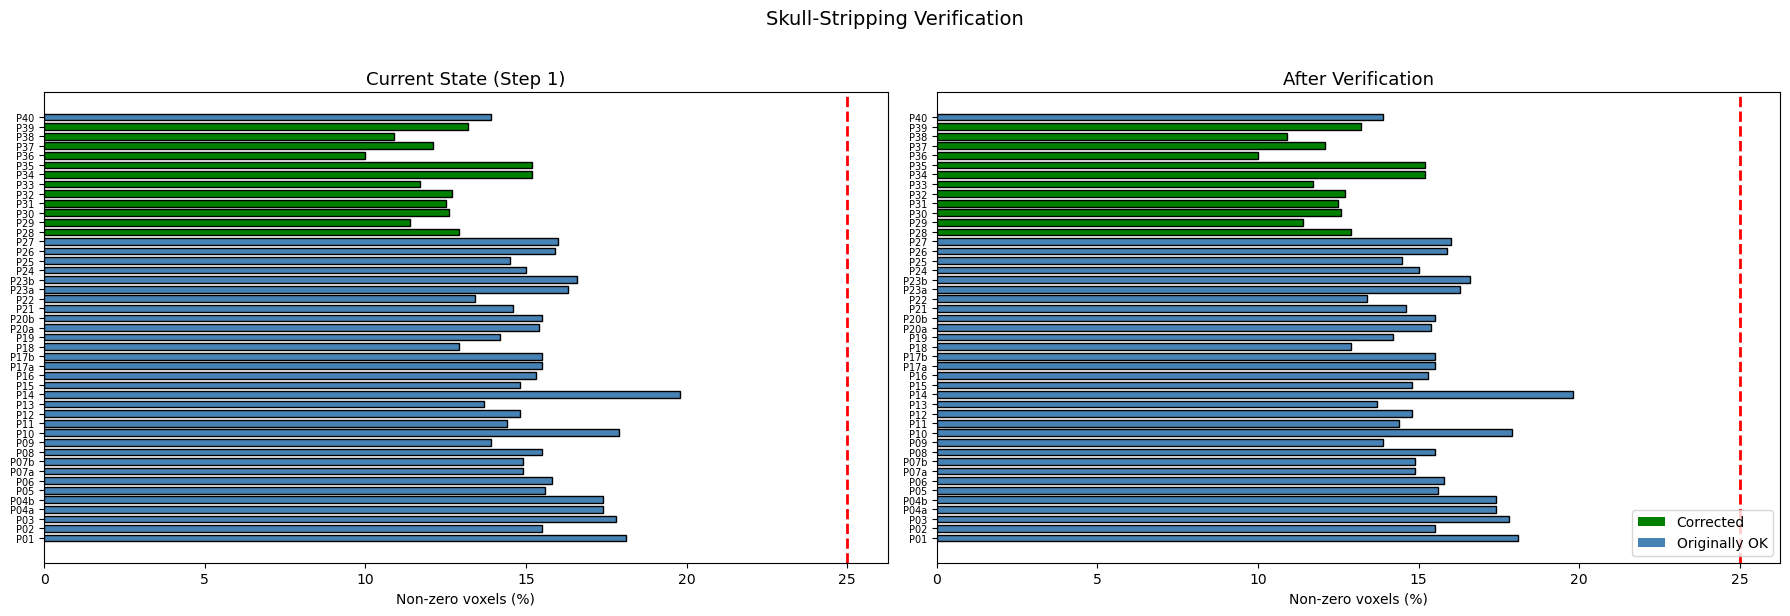

In [8]:
# VERIFICATION: Re-check all patients
verify_data = []
for patient in tqdm(all_patients, desc='Verifying'):
    t1c = DATA_ROOT / patient / 'BraTS' / 'baseline' / 't1c.nii.gz'
    if not t1c.exists(): continue
    d = nib.load(t1c).get_fdata()
    nz_pct = (d != 0).sum() / d.size * 100
    has_backup = (BACKUP_DIR / patient / 'baseline' / 't1c.nii.gz').exists()
    verify_data.append({'Patient': patient, 'NonZero_Pct': round(nz_pct, 1),
                        'Was_Corrected': has_backup})

df_verify = pd.DataFrame(verify_data)
still_high = df_verify[df_verify['NonZero_Pct'] > 25]

print(f'Verification Results:')
print(f'  Total patients: {len(df_verify)}')
print(f'  All below 25%: {len(still_high) == 0}')
if len(still_high) > 0:
    print(f'  Still above 25%: {still_high[["Patient","NonZero_Pct"]].to_string(index=False)}')
print(f'  Mean non-zero: {df_verify["NonZero_Pct"].mean():.1f}%')
print(f'  Range: {df_verify["NonZero_Pct"].min():.1f}% -- {df_verify["NonZero_Pct"].max():.1f}%')

# Before vs After comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Before (from df_strip)
color_map_b = {'Stripped': 'steelblue', 'NOT stripped': 'orangered', 'Already corrected': 'green'}
colors_before = [color_map_b[s] for s in df_strip['Status']]
axes[0].barh(df_strip['Patient'], df_strip['NonZero_Pct'], color=colors_before, edgecolor='k', height=0.7)
axes[0].axvline(25, color='red', ls='--', lw=2)
axes[0].set_xlabel('Non-zero voxels (%)')
axes[0].set_title('Current State (Step 1)', fontsize=13)
axes[0].tick_params(axis='y', labelsize=7)

# After
colors_after = ['green' if w else 'steelblue' for w in df_verify['Was_Corrected']]
axes[1].barh(df_verify['Patient'], df_verify['NonZero_Pct'], color=colors_after, edgecolor='k', height=0.7)
axes[1].axvline(25, color='red', ls='--', lw=2)
axes[1].set_xlabel('Non-zero voxels (%)')
axes[1].set_title('After Verification', fontsize=13)
axes[1].tick_params(axis='y', labelsize=7)
from matplotlib.patches import Patch as P3
axes[1].legend(handles=[P3(fc='green', label='Corrected'), P3(fc='steelblue', label='Originally OK')],
               loc='lower right')

plt.suptitle('Skull-Stripping Verification', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'skull_stripping_verification.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 5: Visual Comparison After Stripping

Show the same patients from Step 2, now with skull-stripping applied.

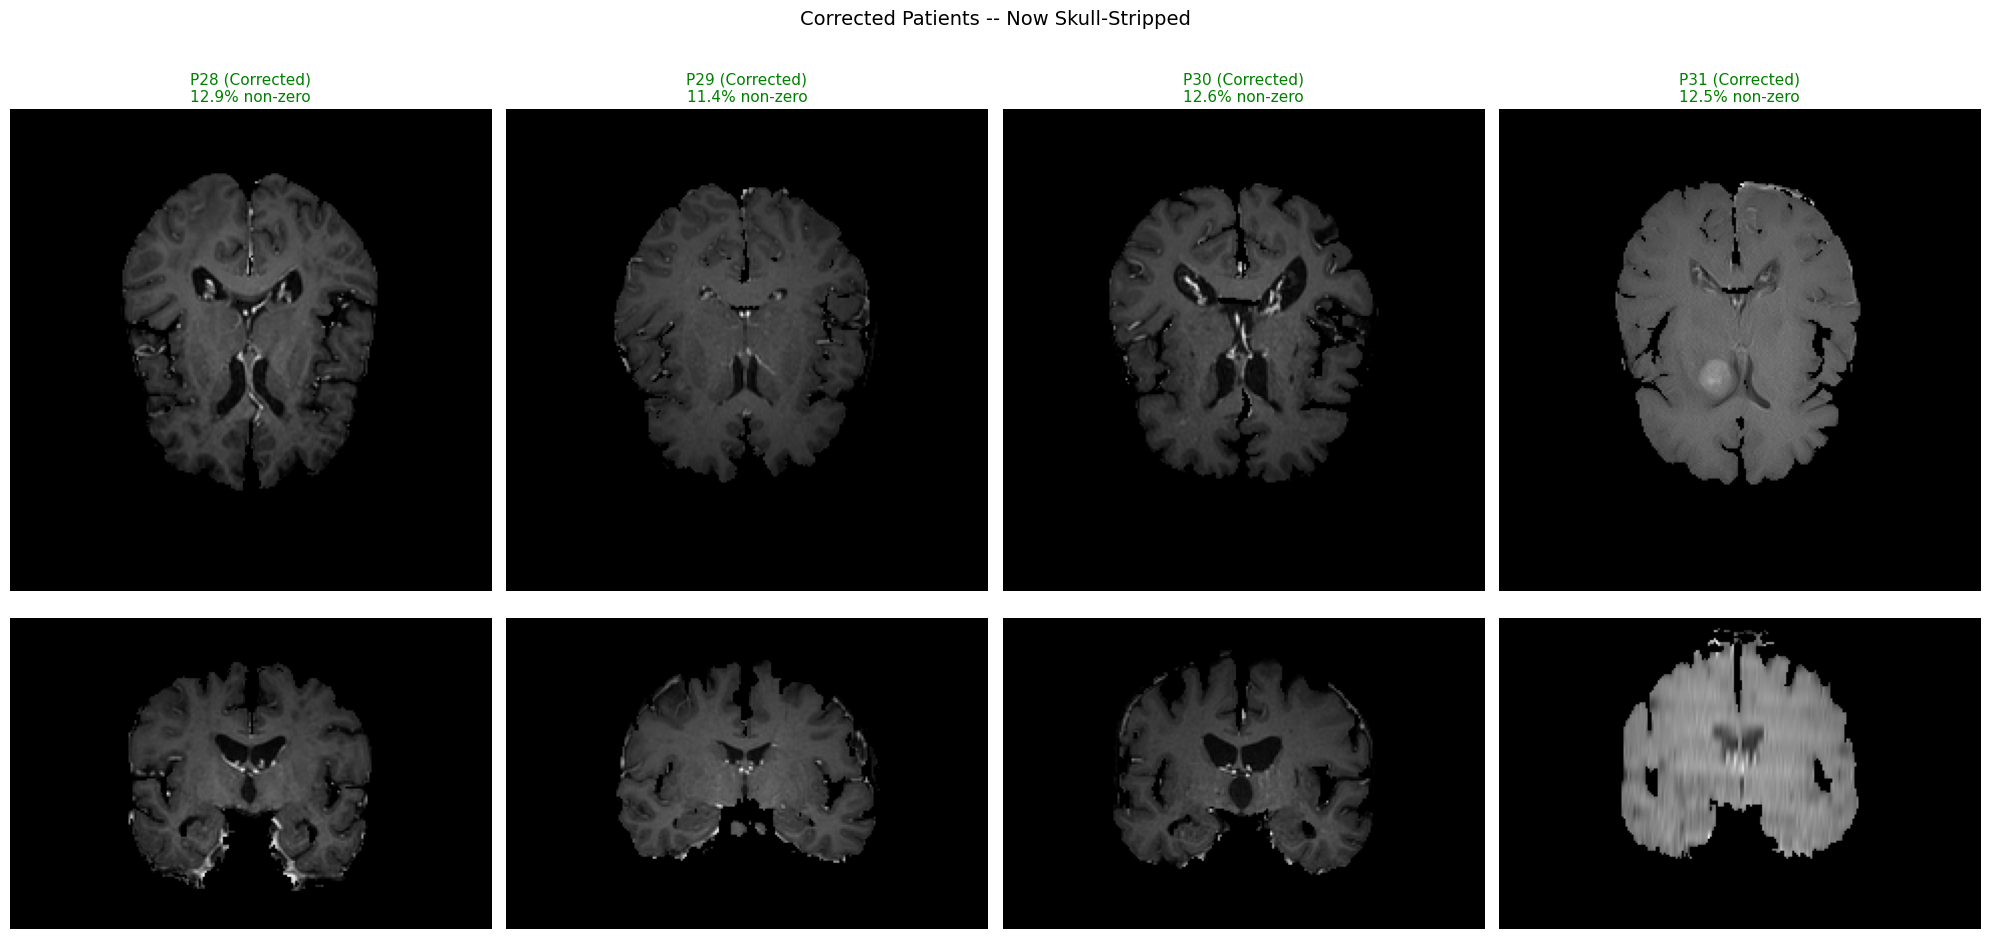

All 45 patients are now skull-stripped and ready for Phase 2.
Original files backed up to: /home/moamed/canada_me/explainable_diseas/implementation_cyprus/outputs/pre_skullstrip_backup


In [9]:
# Final visual: show corrected patients are now brain-only
corrected_patients = df_verify[df_verify['Was_Corrected']]
if len(corrected_patients) == 0:
    print('No corrected patients to show (all were already OK)')
else:
    show = corrected_patients.head(4)
    fig, axes = plt.subplots(2, len(show), figsize=(5*len(show), 10))
    if len(show) == 1: axes = axes.reshape(-1, 1)
    
    for col, (_, row) in enumerate(show.iterrows()):
        patient = row['Patient']
        t1c = nib.load(DATA_ROOT / patient / 'BraTS' / 'baseline' / 't1c.nii.gz').get_fdata()
        mid_z = t1c.shape[2] // 2
        mid_y = t1c.shape[1] // 2
        
        axes[0, col].imshow(np.rot90(t1c[:, :, mid_z]), cmap='gray')
        axes[0, col].set_title(f'{patient} (Corrected)\n{row["NonZero_Pct"]}% non-zero',
                              fontsize=11, color='green')
        axes[0, col].axis('off')
        if col == 0: axes[0, col].set_ylabel('Axial', fontsize=12)
        
        axes[1, col].imshow(np.rot90(t1c[:, mid_y, :]), cmap='gray')
        axes[1, col].axis('off')
        if col == 0: axes[1, col].set_ylabel('Coronal', fontsize=12)
    
    plt.suptitle('Corrected Patients -- Now Skull-Stripped', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

print(f'All {len(df_verify)} patients are now skull-stripped and ready for Phase 2.')
print(f'Original files backed up to: {BACKUP_DIR}')